# Gyro / IMU Log Analysis

This notebook analyzes `Data/gyro_log.csv`. The file name says gyro, but the current CSV schema does not contain angular-rate columns such as `gx`, `gy`, or `gz`; it contains acceleration, barometer, GPS, fix, and satellite fields.

The notebook is defensive: placeholder values are converted to `NaN`, GPS points are filtered before mapping, and `time_ms` resets are handled by building a continuous elapsed-time column.


In [1]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 80)
plt.style.use("seaborn-v0_8-whitegrid")

# Works when the notebook is opened from the repository root or from Data/.
CANDIDATE_PATHS = [Path("Data/gyro_log.csv"), Path("gyro_log.csv")]
CSV_PATH = next((p for p in CANDIDATE_PATHS if p.exists()), CANDIDATE_PATHS[0])
DATA_DIR = CSV_PATH.parent if CSV_PATH.parent != Path("") else Path(".")
CLEAN_CSV_PATH = DATA_DIR / "gyro_analysis_clean.csv"

print(f"Reading: {CSV_PATH.resolve()}")


Reading: /home/drasogun/DraSoGun/Work/CANSAT_Duck2Dragon/Data/gyro_log.csv


## Load Data

Read the CSV, coerce numeric columns safely, and show the raw shape and columns before cleaning.


In [2]:
df_raw = pd.read_csv(CSV_PATH)

expected_columns = [
    "idx", "time_ms", "temp_C", "pres_Pa", "alt_m",
    "ax_g", "ay_g", "az_g", "lat", "lon", "gps_alt_m",
    "spd_kn", "fix", "sats",
]
missing = [col for col in expected_columns if col not in df_raw.columns]
extra = [col for col in df_raw.columns if col not in expected_columns]

print(f"Rows: {len(df_raw):,}")
print(f"Columns: {len(df_raw.columns)}")
print("Missing expected columns:", missing if missing else "none")
print("Extra columns:", extra if extra else "none")
display(df_raw.head(10))
display(df_raw.dtypes.to_frame("dtype"))


Rows: 70
Columns: 14
Missing expected columns: none
Extra columns: none


,idx,time_ms,temp_C,pres_Pa,alt_m,ax_g,ay_g,az_g,lat,lon,gps_alt_m,spd_kn,fix,sats
0,47,213283,-999.0,0.0,0.0,0.0,0.0,0.0,12.608765,100.941322,-0.8,0.03,1,12
1,48,223317,-999.0,0.0,0.0,0.0,0.0,0.0,12.608765,100.941322,-0.8,0.03,1,12
2,49,233351,-999.0,0.0,0.0,0.0,0.0,0.0,12.608765,100.941322,-0.8,0.03,1,12
3,50,243385,-999.0,0.0,0.0,0.0,0.0,0.0,12.608772,100.941330,-0.9,0.06,1,12
4,51,253419,-999.0,0.0,0.0,0.0,0.0,0.0,12.608772,100.941330,-0.9,0.06,1,12
5,52,263453,-999.0,0.0,0.0,0.0,0.0,0.0,12.608772,100.941330,-0.9,0.06,1,12
6,53,273487,-999.0,0.0,0.0,0.0,0.0,0.0,12.608777,100.941330,10.0,0.06,1,12
7,54,283550,-999.0,0.0,0.0,0.0,0.0,0.0,12.608777,100.941330,-0.2,0.06,1,12
8,55,293584,-999.0,0.0,0.0,0.0,0.0,0.0,12.608778,100.941330,-0.2,0.03,1,12
9,56,303618,-999.0,0.0,0.0,0.0,0.0,0.0,12.608778,100.941338,-0.3,0.03,1,12


,dtype
idx,int64
time_ms,int64
temp_C,float64
pres_Pa,float64
alt_m,float64
ax_g,float64
ay_g,float64
az_g,float64
lat,float64
lon,float64


## Clean Invalid Values

The log uses several placeholder values when sensors are not ready. This step converts those placeholders to `NaN` so the plots and statistics do not treat them as real measurements.


In [3]:
df = df_raw.copy()

# Coerce expected numeric columns. If a value is malformed, keep the row and mark only that field as NaN.
for col in expected_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Sensor placeholder cleanup.
if "temp_C" in df:
    df.loc[df["temp_C"] <= -900, "temp_C"] = np.nan
if "pres_Pa" in df:
    df.loc[df["pres_Pa"] <= 0, "pres_Pa"] = np.nan
if "alt_m" in df:
    # Keep zero altitude only if pressure is valid; otherwise it is probably a placeholder row.
    invalid_alt = df["alt_m"].eq(0) & df.get("pres_Pa", pd.Series(np.nan, index=df.index)).isna()
    df.loc[invalid_alt, "alt_m"] = np.nan

# Acceleration: all-zero vectors are usually startup/default rows, not real IMU samples.
accel_cols = [c for c in ["ax_g", "ay_g", "az_g"] if c in df.columns]
if len(accel_cols) == 3:
    accel_zero = df[accel_cols].fillna(0).abs().sum(axis=1).eq(0)
    df.loc[accel_zero, accel_cols] = np.nan

# GPS validity mask. Keep original lat/lon columns, but create cleaned columns for analysis.
for col in ["lat", "lon", "gps_alt_m", "spd_kn", "fix", "sats"]:
    if col not in df.columns:
        df[col] = np.nan

gps_valid = (
    df["lat"].notna() & df["lon"].notna()
    & df["lat"].between(-90, 90) & df["lon"].between(-180, 180)
    & df["lat"].ne(0) & df["lon"].ne(0)
    & df["fix"].fillna(0).gt(0)
    & df["sats"].fillna(0).gt(0)
)
df["gps_valid"] = gps_valid
df["lat_clean"] = df["lat"].where(gps_valid)
df["lon_clean"] = df["lon"].where(gps_valid)
df["gps_alt_clean_m"] = df["gps_alt_m"].where(gps_valid)
df["speed_mps"] = df["spd_kn"] * 0.514444

invalid_counts = pd.DataFrame({
    "missing_or_invalid": df.isna().sum(),
    "valid_count": df.notna().sum(),
})
display(invalid_counts)
display(df.head(10))


,missing_or_invalid,valid_count
idx,0,70
time_ms,0,70
temp_C,70,0
pres_Pa,70,0
alt_m,70,0
ax_g,70,0
ay_g,70,0
az_g,70,0
lat,0,70
lon,0,70


,idx,time_ms,temp_C,pres_Pa,alt_m,ax_g,ay_g,az_g,lat,lon,gps_alt_m,spd_kn,fix,sats,gps_valid,lat_clean,lon_clean,gps_alt_clean_m,speed_mps
0,47,213283,NaN,NaN,NaN,NaN,NaN,NaN,12.608765,100.941322,-0.8,0.03,1,12,True,12.608765,100.941322,-0.8,0.015433
1,48,223317,NaN,NaN,NaN,NaN,NaN,NaN,12.608765,100.941322,-0.8,0.03,1,12,True,12.608765,100.941322,-0.8,0.015433
2,49,233351,NaN,NaN,NaN,NaN,NaN,NaN,12.608765,100.941322,-0.8,0.03,1,12,True,12.608765,100.941322,-0.8,0.015433
3,50,243385,NaN,NaN,NaN,NaN,NaN,NaN,12.608772,100.941330,-0.9,0.06,1,12,True,12.608772,100.941330,-0.9,0.030867
4,51,253419,NaN,NaN,NaN,NaN,NaN,NaN,12.608772,100.941330,-0.9,0.06,1,12,True,12.608772,100.941330,-0.9,0.030867
5,52,263453,NaN,NaN,NaN,NaN,NaN,NaN,12.608772,100.941330,-0.9,0.06,1,12,True,12.608772,100.941330,-0.9,0.030867
6,53,273487,NaN,NaN,NaN,NaN,NaN,NaN,12.608777,100.941330,10.0,0.06,1,12,True,12.608777,100.941330,10.0,0.030867
7,54,283550,NaN,NaN,NaN,NaN,NaN,NaN,12.608777,100.941330,-0.2,0.06,1,12,True,12.608777,100.941330,-0.2,0.030867
8,55,293584,NaN,NaN,NaN,NaN,NaN,NaN,12.608778,100.941330,-0.2,0.03,1,12,True,12.608778,100.941330,-0.2,0.015433
9,56,303618,NaN,NaN,NaN,NaN,NaN,NaN,12.608778,100.941338,-0.3,0.03,1,12,True,12.608778,100.941338,-0.3,0.015433


## Time Reconstruction

`time_ms` can reset when the board restarts. This creates `segment` and a continuous `time_s` column for plotting.


In [4]:
if "time_ms" not in df.columns:
    df["time_ms"] = np.arange(len(df), dtype=float)

time_ms = pd.to_numeric(df["time_ms"], errors="coerce")
raw_dt_s = time_ms.diff() / 1000.0

# Start a new segment when time moves backwards or jumps to an invalid value.
reset_mask = raw_dt_s.lt(0) | raw_dt_s.isna()
reset_mask.iloc[0] = True
df["segment"] = reset_mask.cumsum() - 1

positive_dt = raw_dt_s[(raw_dt_s > 0) & (raw_dt_s < 60)]
median_dt = float(positive_dt.median()) if len(positive_dt) else 0.0

# For continuous plotting, ignore negative/reset deltas and unrealistic large gaps.
dt_s = raw_dt_s.copy()
dt_s[(dt_s <= 0) | (dt_s > 60) | dt_s.isna()] = median_dt
dt_s.iloc[0] = 0.0
df["dt_s"] = dt_s
df["time_s"] = dt_s.cumsum()
df["time_min"] = df["time_s"] / 60.0
df["time_raw_s"] = time_ms / 1000.0

print(f"Detected time segments: {df['segment'].nunique()}")
print(f"Median positive dt: {median_dt:.3f} s")
print(f"Estimated duration: {df['time_s'].max():.2f} s")
display(df[["idx", "time_ms", "segment", "dt_s", "time_s"]].head(20))


Detected time segments: 2
Median positive dt: 10.034 s
Estimated duration: 713.19 s


,idx,time_ms,segment,dt_s,time_s
0,47,213283,0,0.000,0.000
1,48,223317,0,10.034,10.034
2,49,233351,0,10.034,20.068
3,50,243385,0,10.034,30.102
4,51,253419,0,10.034,40.136
5,52,263453,0,10.034,50.170
6,53,273487,0,10.034,60.204
7,54,283550,0,10.063,70.267
8,55,293584,0,10.034,80.301
9,56,303618,0,10.034,90.335


## Derived Measurements

Compute acceleration magnitude, relative altitude, and estimated vertical speed. These derived columns make it easier to find movement, launch-like events, and bad sensor sections.


In [5]:
if len(accel_cols) == 3:
    df["accel_mag_g"] = np.sqrt(df["ax_g"]**2 + df["ay_g"]**2 + df["az_g"]**2)
    df["accel_dynamic_g"] = (df["accel_mag_g"] - 1.0).abs()
else:
    df["accel_mag_g"] = np.nan
    df["accel_dynamic_g"] = np.nan

def relative_to_first_valid(series):
    valid = series.dropna()
    if valid.empty:
        return pd.Series(np.nan, index=series.index)
    return series - valid.iloc[0]

df["baro_alt_rel_m"] = relative_to_first_valid(df.get("alt_m", pd.Series(np.nan, index=df.index)))
df["gps_alt_rel_m"] = relative_to_first_valid(df.get("gps_alt_clean_m", pd.Series(np.nan, index=df.index)))

# Smooth before differentiating to reduce noise. Use time_s spacing when possible.
alt_smooth = df["baro_alt_rel_m"].rolling(window=5, min_periods=1, center=True).median()
time_values = df["time_s"].to_numpy(dtype=float)
alt_values = alt_smooth.to_numpy(dtype=float)
if np.isfinite(alt_values).sum() >= 2 and np.nanmax(time_values) > np.nanmin(time_values):
    filled_alt = pd.Series(alt_values).interpolate(limit_direction="both").to_numpy(dtype=float)
    df["vertical_speed_mps"] = np.gradient(filled_alt, time_values)
else:
    df["vertical_speed_mps"] = np.nan

derived_cols = [
    "time_s", "segment", "accel_mag_g", "accel_dynamic_g",
    "baro_alt_rel_m", "gps_alt_rel_m", "speed_mps", "vertical_speed_mps",
]
display(df[derived_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
time_s,70.0,358.060600,212.899512,0.0,173.115500,366.304000,539.482500,713.193000
segment,70.0,0.357143,0.482617,0.0,0.000000,0.000000,1.000000,1.000000
accel_mag_g,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accel_dynamic_g,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
baro_alt_rel_m,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gps_alt_rel_m,65.0,8.115385,36.354377,-1.2,0.500000,2.000000,5.100000,293.500000
speed_mps,70.0,1.063797,4.620025,0.0,0.005144,0.010289,0.030867,23.854768
vertical_speed_mps,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Summary

Quick health check for the log.


In [6]:
summary = {
    "rows": len(df),
    "time_segments": int(df["segment"].nunique()),
    "duration_s": float(df["time_s"].max()) if len(df) else np.nan,
    "valid_accel_rows": int(df["accel_mag_g"].notna().sum()),
    "valid_baro_rows": int(df["pres_Pa"].notna().sum()) if "pres_Pa" in df else 0,
    "valid_gps_rows": int(df["gps_valid"].sum()),
    "max_accel_g": float(df["accel_mag_g"].max()) if df["accel_mag_g"].notna().any() else np.nan,
    "max_baro_alt_rel_m": float(df["baro_alt_rel_m"].max()) if df["baro_alt_rel_m"].notna().any() else np.nan,
    "max_gps_alt_rel_m": float(df["gps_alt_rel_m"].max()) if df["gps_alt_rel_m"].notna().any() else np.nan,
    "max_speed_mps": float(df["speed_mps"].max()) if df["speed_mps"].notna().any() else np.nan,
    "max_sats": float(df["sats"].max()) if df["sats"].notna().any() else np.nan,
}
summary_df = pd.DataFrame.from_dict(summary, orient="index", columns=["value"])
display(summary_df)

if summary["valid_gps_rows"] == 0:
    print("No valid GPS fix rows found. Map/track plots will be skipped.")
if summary["valid_accel_rows"] == 0:
    print("No valid acceleration rows found after removing all-zero placeholder vectors.")


,value
rows,70.000000
time_segments,2.000000
duration_s,713.193000
valid_accel_rows,0.000000
valid_baro_rows,0.000000
valid_gps_rows,65.000000
max_accel_g,NaN
max_baro_alt_rel_m,NaN
max_gps_alt_rel_m,293.500000
max_speed_mps,23.854768


No valid acceleration rows found after removing all-zero placeholder vectors.


## Acceleration Plots


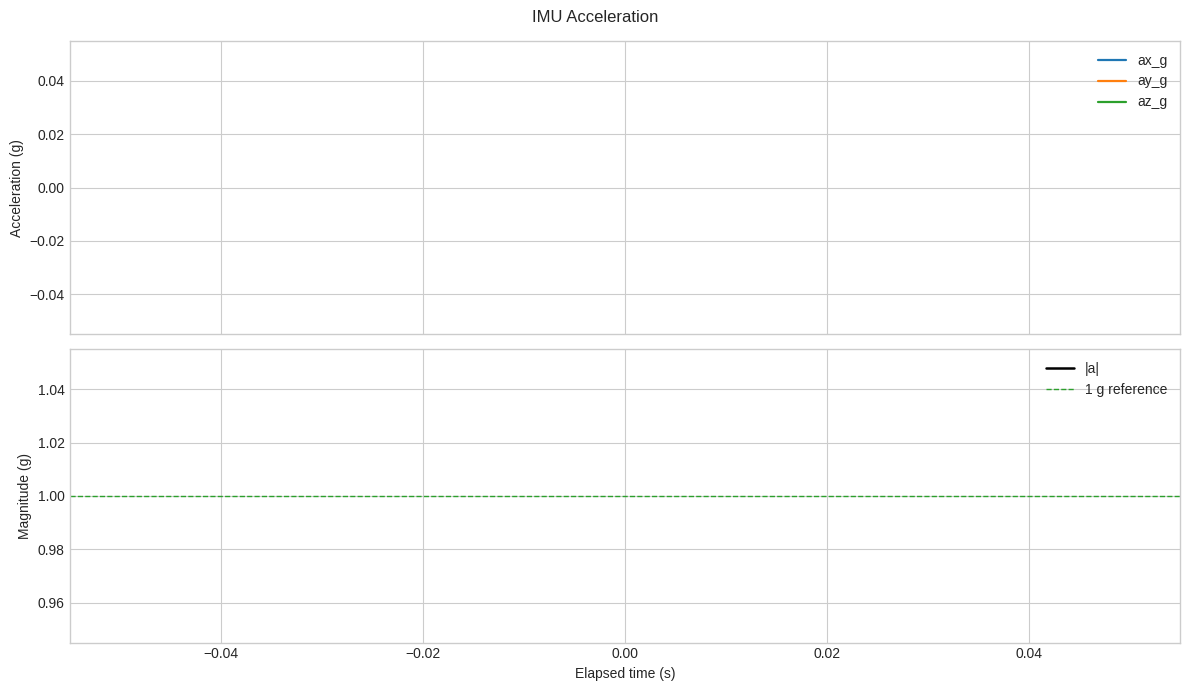

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

if len(accel_cols) == 3:
    axes[0].plot(df["time_s"], df["ax_g"], label="ax_g", linewidth=1.6)
    axes[0].plot(df["time_s"], df["ay_g"], label="ay_g", linewidth=1.6)
    axes[0].plot(df["time_s"], df["az_g"], label="az_g", linewidth=1.6)
    axes[0].set_ylabel("Acceleration (g)")
    axes[0].legend(loc="best")

axes[1].plot(df["time_s"], df["accel_mag_g"], label="|a|", color="black", linewidth=1.8)
axes[1].axhline(1.0, color="tab:green", linestyle="--", linewidth=1, label="1 g reference")
axes[1].set_xlabel("Elapsed time (s)")
axes[1].set_ylabel("Magnitude (g)")
axes[1].legend(loc="best")

fig.suptitle("IMU Acceleration")
fig.tight_layout()
plt.show()


## Barometer and Altitude Plots


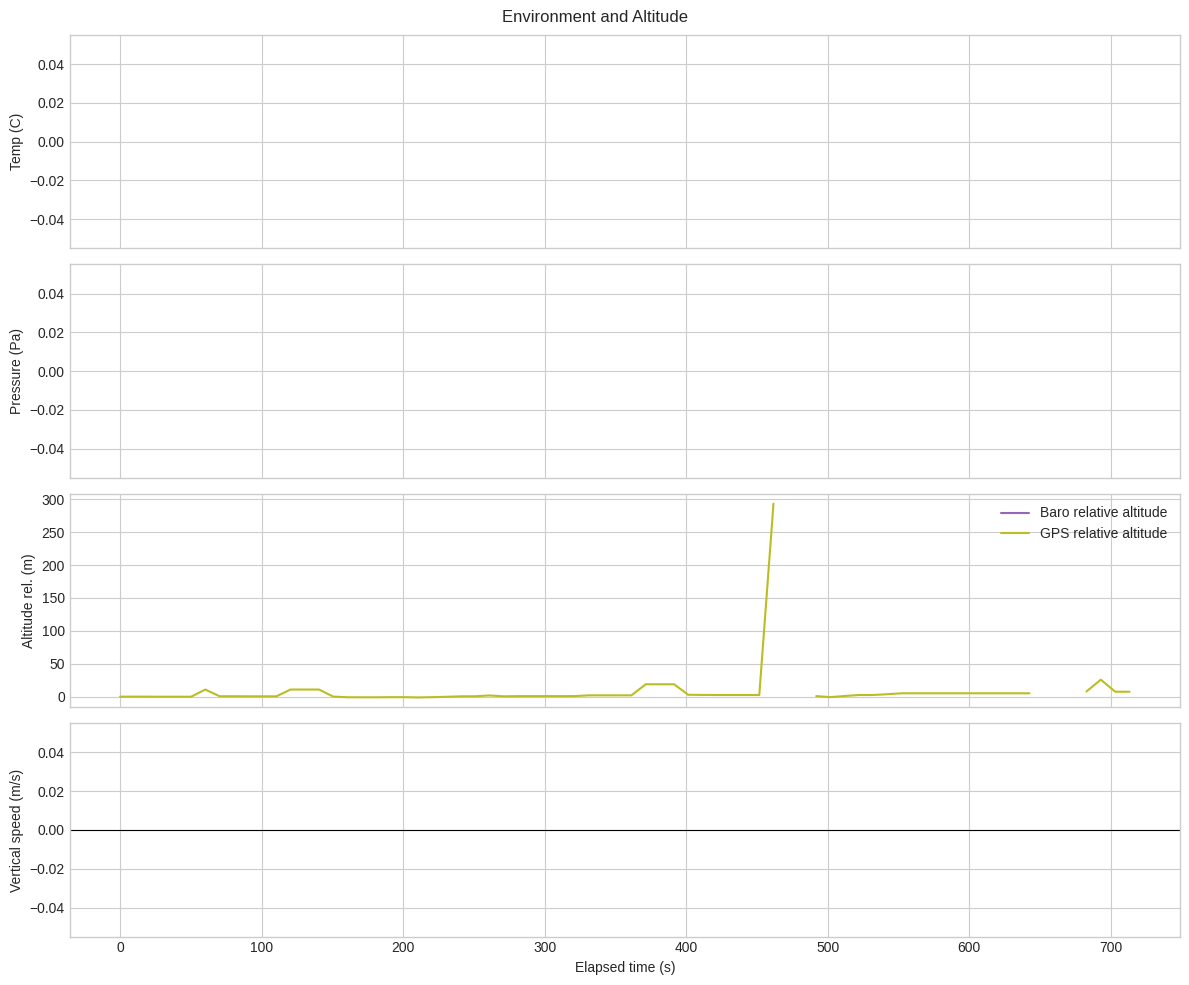

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(df["time_s"], df.get("temp_C", np.nan), color="tab:red")
axes[0].set_ylabel("Temp (C)")

axes[1].plot(df["time_s"], df.get("pres_Pa", np.nan), color="tab:blue")
axes[1].set_ylabel("Pressure (Pa)")

axes[2].plot(df["time_s"], df.get("baro_alt_rel_m", np.nan), color="tab:purple", label="Baro relative altitude")
axes[2].plot(df["time_s"], df.get("gps_alt_rel_m", np.nan), color="tab:olive", label="GPS relative altitude")
axes[2].set_ylabel("Altitude rel. (m)")
axes[2].legend(loc="best")

axes[3].plot(df["time_s"], df.get("vertical_speed_mps", np.nan), color="tab:orange")
axes[3].axhline(0, color="black", linewidth=0.8)
axes[3].set_ylabel("Vertical speed (m/s)")
axes[3].set_xlabel("Elapsed time (s)")

fig.suptitle("Environment and Altitude")
fig.tight_layout()
plt.show()


## GPS, Fix, and Satellites


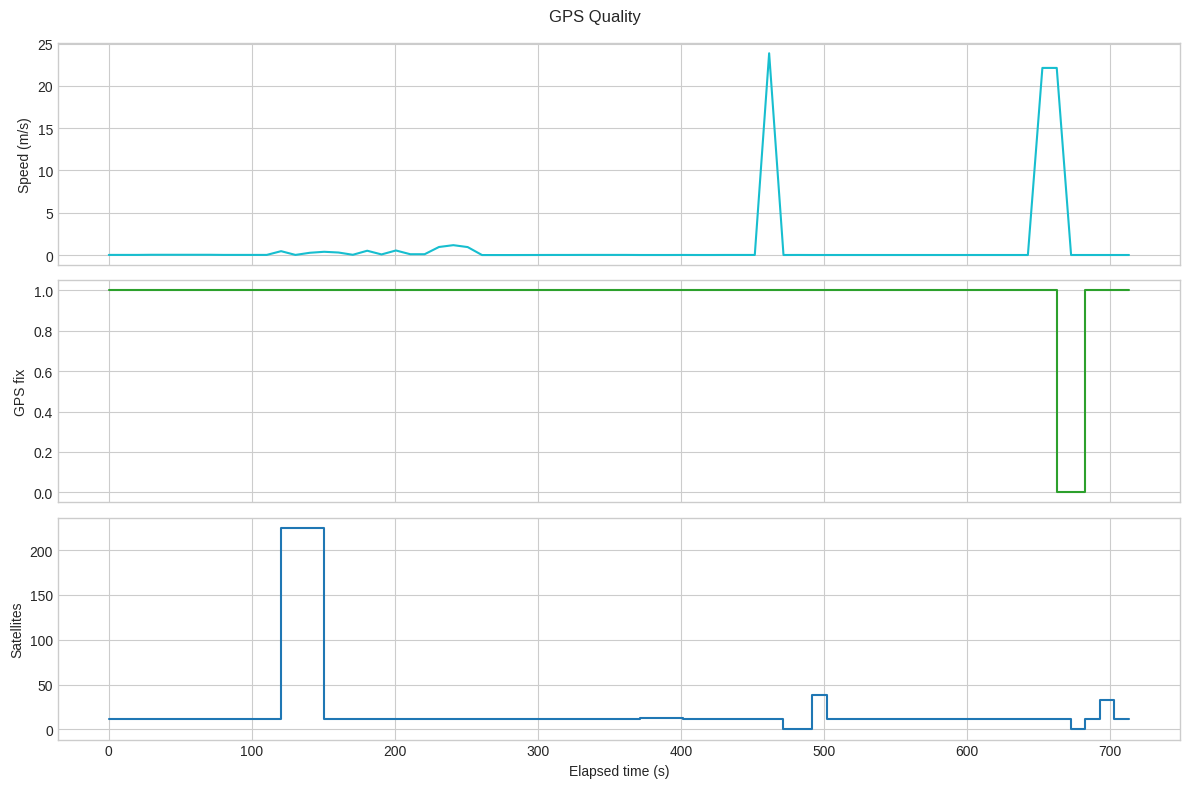

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df["time_s"], df.get("speed_mps", np.nan), color="tab:cyan")
axes[0].set_ylabel("Speed (m/s)")

axes[1].step(df["time_s"], df.get("fix", np.nan), where="post", color="tab:green")
axes[1].set_ylabel("GPS fix")

axes[2].step(df["time_s"], df.get("sats", np.nan), where="post", color="tab:blue")
axes[2].set_ylabel("Satellites")
axes[2].set_xlabel("Elapsed time (s)")

fig.suptitle("GPS Quality")
fig.tight_layout()
plt.show()


## GPS Track

If valid GPS points exist, this cell draws a track. Plotly is used when available for an interactive map; Matplotlib is used as a fallback.


In [10]:
gps_df = df[df["gps_valid"]].copy()

if gps_df.empty:
    print("No valid GPS fix in log. A map cannot be drawn from this file yet.")
else:
    try:
        import plotly.express as px
        fig = px.scatter_mapbox(
            gps_df,
            lat="lat_clean",
            lon="lon_clean",
            # color="gps_alt_clean_m",
            # hover_data=["idx", "time_s", "gps_alt_m", "speed_mps", "fix", "sats"],
            zoom=14,
            height=600,
            # color_continuous_scale="Viridis",
            # labels={"gps_alt_clean_m": "GPS altitude (m)"},
            title=f"GPS Track ({len(gps_df)} valid points)",
            mapbox_style="open-street-map",
        )
        fig.update_layout(margin={"r": 0, "t": 40, "l": 0, "b": 0})
        fig.show()
    except Exception as exc:
        print(f"Plotly map failed, using Matplotlib fallback: {exc}")
        fig, ax = plt.subplots(figsize=(8, 8))
        sc = ax.scatter(gps_df["lon_clean"], gps_df["lat_clean"], c=gps_df["gps_alt_clean_m"], cmap="viridis", s=30)
        ax.plot(gps_df["lon_clean"], gps_df["lat_clean"], color="gray", alpha=0.5, linewidth=1)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_title(f"GPS Track ({len(gps_df)} valid points)")
        ax.axis("equal")
        plt.colorbar(sc, ax=ax, label="GPS altitude (m)")
        plt.show()


/tmp/ipykernel_149704/2414363669.py:8: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


## Sensor Relationships

These quick scatter plots help detect impossible readings and sensor drift.


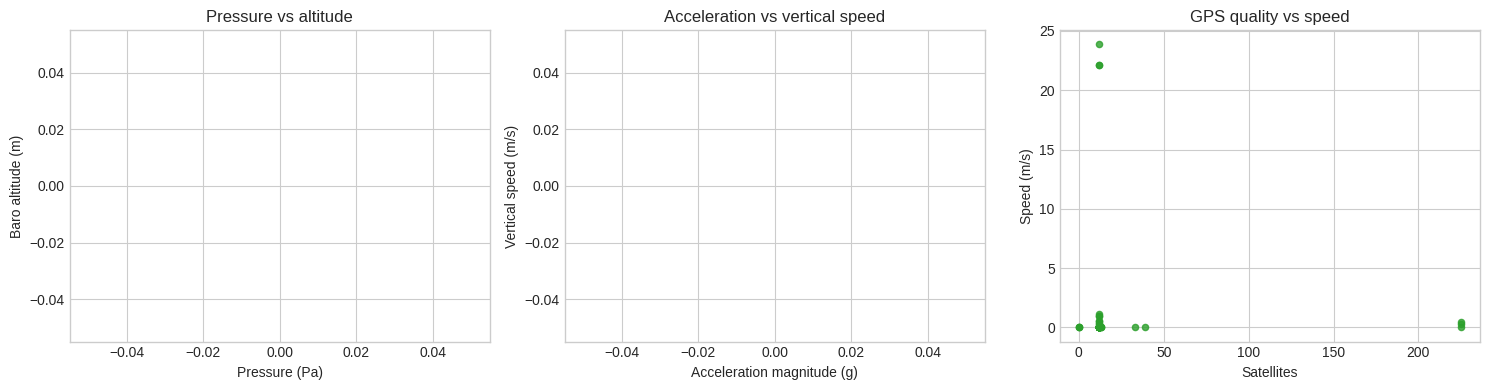

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df.get("pres_Pa", np.nan), df.get("alt_m", np.nan), s=20, alpha=0.8)
axes[0].set_xlabel("Pressure (Pa)")
axes[0].set_ylabel("Baro altitude (m)")
axes[0].set_title("Pressure vs altitude")

axes[1].scatter(df.get("accel_mag_g", np.nan), df.get("vertical_speed_mps", np.nan), s=20, alpha=0.8, color="tab:orange")
axes[1].set_xlabel("Acceleration magnitude (g)")
axes[1].set_ylabel("Vertical speed (m/s)")
axes[1].set_title("Acceleration vs vertical speed")

axes[2].scatter(df.get("sats", np.nan), df.get("speed_mps", np.nan), s=20, alpha=0.8, color="tab:green")
axes[2].set_xlabel("Satellites")
axes[2].set_ylabel("Speed (m/s)")
axes[2].set_title("GPS quality vs speed")

fig.tight_layout()
plt.show()


## Event Detection Helpers

This is a simple starting point for finding interesting rows, such as high acceleration or fast altitude changes.


In [12]:
interesting = df.copy()

accel_threshold = max(2.0, float(df["accel_mag_g"].quantile(0.95)) if df["accel_mag_g"].notna().any() else 2.0)
vertical_speed_threshold = max(5.0, float(df["vertical_speed_mps"].abs().quantile(0.95)) if df["vertical_speed_mps"].notna().any() else 5.0)

event_mask = (
    df["accel_mag_g"].fillna(0).ge(accel_threshold)
    | df["vertical_speed_mps"].abs().fillna(0).ge(vertical_speed_threshold)
)
events = interesting.loc[event_mask, [
    "idx", "time_s", "segment", "accel_mag_g", "vertical_speed_mps",
    "baro_alt_rel_m", "gps_alt_rel_m", "lat_clean", "lon_clean", "fix", "sats",
]].copy()

print(f"Acceleration event threshold: {accel_threshold:.3f} g")
print(f"Vertical-speed event threshold: {vertical_speed_threshold:.3f} m/s")
print(f"Detected event rows: {len(events)}")
display(events.head(30))


Acceleration event threshold: 2.000 g
Vertical-speed event threshold: 5.000 m/s
Detected event rows: 0


,idx,time_s,segment,accel_mag_g,vertical_speed_mps,baro_alt_rel_m,gps_alt_rel_m,lat_clean,lon_clean,fix,sats


## Export Cleaned Data

The cleaned CSV keeps the original fields and adds analysis columns such as `time_s`, `segment`, `gps_valid`, `accel_mag_g`, and relative altitude.


In [13]:
df.to_csv(CLEAN_CSV_PATH, index=False)
print(f"Saved cleaned analysis CSV: {CLEAN_CSV_PATH.resolve()}")
print(f"Rows saved: {len(df):,}")
display(df.head(10))


Saved cleaned analysis CSV: /home/drasogun/DraSoGun/Work/CANSAT_Duck2Dragon/Data/gyro_analysis_clean.csv
Rows saved: 70


,idx,time_ms,temp_C,pres_Pa,alt_m,ax_g,ay_g,az_g,lat,lon,gps_alt_m,spd_kn,fix,sats,gps_valid,lat_clean,lon_clean,gps_alt_clean_m,speed_mps,segment,dt_s,time_s,time_min,time_raw_s,accel_mag_g,accel_dynamic_g,baro_alt_rel_m,gps_alt_rel_m,vertical_speed_mps
0,47,213283,NaN,NaN,NaN,NaN,NaN,NaN,12.608765,100.941322,-0.8,0.03,1,12,True,12.608765,100.941322,-0.8,0.015433,0,0.000,0.000,0.000000,213.283,NaN,NaN,NaN,0.0,NaN
1,48,223317,NaN,NaN,NaN,NaN,NaN,NaN,12.608765,100.941322,-0.8,0.03,1,12,True,12.608765,100.941322,-0.8,0.015433,0,10.034,10.034,0.167233,223.317,NaN,NaN,NaN,0.0,NaN
2,49,233351,NaN,NaN,NaN,NaN,NaN,NaN,12.608765,100.941322,-0.8,0.03,1,12,True,12.608765,100.941322,-0.8,0.015433,0,10.034,20.068,0.334467,233.351,NaN,NaN,NaN,0.0,NaN
3,50,243385,NaN,NaN,NaN,NaN,NaN,NaN,12.608772,100.941330,-0.9,0.06,1,12,True,12.608772,100.941330,-0.9,0.030867,0,10.034,30.102,0.501700,243.385,NaN,NaN,NaN,-0.1,NaN
4,51,253419,NaN,NaN,NaN,NaN,NaN,NaN,12.608772,100.941330,-0.9,0.06,1,12,True,12.608772,100.941330,-0.9,0.030867,0,10.034,40.136,0.668933,253.419,NaN,NaN,NaN,-0.1,NaN
5,52,263453,NaN,NaN,NaN,NaN,NaN,NaN,12.608772,100.941330,-0.9,0.06,1,12,True,12.608772,100.941330,-0.9,0.030867,0,10.034,50.170,0.836167,263.453,NaN,NaN,NaN,-0.1,NaN
6,53,273487,NaN,NaN,NaN,NaN,NaN,NaN,12.608777,100.941330,10.0,0.06,1,12,True,12.608777,100.941330,10.0,0.030867,0,10.034,60.204,1.003400,273.487,NaN,NaN,NaN,10.8,NaN
7,54,283550,NaN,NaN,NaN,NaN,NaN,NaN,12.608777,100.941330,-0.2,0.06,1,12,True,12.608777,100.941330,-0.2,0.030867,0,10.063,70.267,1.171117,283.550,NaN,NaN,NaN,0.6,NaN
8,55,293584,NaN,NaN,NaN,NaN,NaN,NaN,12.608778,100.941330,-0.2,0.03,1,12,True,12.608778,100.941330,-0.2,0.015433,0,10.034,80.301,1.338350,293.584,NaN,NaN,NaN,0.6,NaN
9,56,303618,NaN,NaN,NaN,NaN,NaN,NaN,12.608778,100.941338,-0.3,0.03,1,12,True,12.608778,100.941338,-0.3,0.015433,0,10.034,90.335,1.505583,303.618,NaN,NaN,NaN,0.5,NaN
